<a href="https://colab.research.google.com/github/SinthiyaMoses/AIML/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving Social_Network_Ads.csv to Social_Network_Ads.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load the CSV file
df = pd.read_csv('Social_Network_Ads.csv')

# Show first 5 rows
df.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
print("Dataset info:")
print(df.info())
print("\nClass distribution:")
print(df['Purchased'].value_counts())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None

Class distribution:
Purchased
0    257
1    143
Name: count, dtype: int64


In [5]:
# Drop unnecessary column (User ID)
if 'User ID' in df.columns:
    df.drop('User ID', axis=1, inplace=True)

# Encode Gender (Male/Female → 0/1)
if 'Gender' in df.columns:
    le = LabelEncoder()
    df['Gender'] = le.fit_transform(df['Gender'])

# Define features (X) and target (y)
X = df.drop('Purchased', axis=1)
y = df['Purchased']

# Split data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [6]:
kernels = ['linear', 'rbf']

for kernel in kernels:
    print(f"\n🔹 Kernel: {kernel.upper()}")
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")



🔹 Kernel: LINEAR
Accuracy: 0.8625

🔹 Kernel: RBF
Accuracy: 0.9250


In [7]:
# Define parameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=5)
grid.fit(X_train, y_train)

print("\n✅ Best Parameters:", grid.best_params_)
print("✅ Best Accuracy:", grid.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
✅ Best Accuracy: 0.915625



Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80


Confusion Matrix:
 [[48  4]
 [ 2 26]]


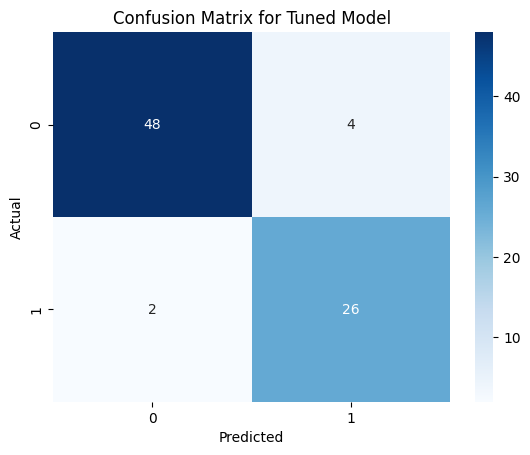

In [8]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Tuned Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [9]:
print("✅ Kernel Comparison Complete!")
print("✅ Tuned Model Achieved Accuracy:", accuracy_score(y_test, y_pred))


✅ Kernel Comparison Complete!
✅ Tuned Model Achieved Accuracy: 0.925
